## import

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import utils
from utils import load_configs
from utils import log_model_info
# === LOAD CONFIG FILES ===
config = load_configs(r"E:\MTP_DATA\Final-MTP\config\train.yaml")
print("Loaded config file")

# === CONFIG ===
DATA_DIR = config['dir']['train']  # Path to your dataset
IMG_SIZE = config['image']['img_size']  # Size of the images (height, width)
FRAMES_PER_SAMPLE = config['image']['frames_per_sample']  # Number of frames per sample
NUM_CLASSES = config['model']['num_classes']  # Number of classes
CHANNELS_PER_FRAME = config['image']["channels"]  # Grayscale
TOTAL_CHANNELS = FRAMES_PER_SAMPLE * CHANNELS_PER_FRAME
EPOCHS = config['model']['epochs']  # Number of epochs for training
BATCH_SIZE = config['model']['batch_size']  # Batch size for training
MODEL_DIR = config['dir']['save_dir']  # Directory to save the model
MODEL_NAME = config['model']['name']  # Name of the model
CPU_MODEL = os.path.join(MODEL_DIR, MODEL_NAME + '.h5')  # Full path to save the model
TFLITE_MODEL = os.path.join(MODEL_DIR, MODEL_NAME + '.tflite')  # Full path to save the TFLite model
TPU_MODEL = os.path.join(MODEL_DIR, MODEL_NAME + '_edgetpu.tflite')  # Full path to save the TPU mode



: 

## Dataset

In [2]:
# === LOAD SEQUENCES ===
def load_sequence_images(label_folder, label_index):
    images = []
    image_files = sorted(os.listdir(label_folder))
    for i in range(0, len(image_files) - FRAMES_PER_SAMPLE + 1):
        frame_stack = []
        for j in range(FRAMES_PER_SAMPLE):
            img_path = os.path.join(label_folder, image_files[i + j])
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            frame_stack.append(img)
        stacked = np.stack(frame_stack, axis=-1)  # shape: (224, 224, 10) instead of (224, 224, 30)
        images.append(stacked)
    labels = [label_index] * len(images)
    return images, labels

# === LOAD ENTIRE DATASET ===
X, y = [], []
class_names = sorted(os.listdir(DATA_DIR))
for idx, label in enumerate(class_names):
    print(f"[info] Loading... {label}")
    folder_path = os.path.join(DATA_DIR, label)
    if os.path.isdir(folder_path):
        imgs, lbls = load_sequence_images(folder_path, idx)
        X.extend(imgs)
        y.extend(lbls)

X = np.array(X, dtype=np.uint8)  # Required for uint8 quantization
X_normalized = X.astype(np.float32) / 255.0  # Used for training
y = tf.keras.utils.to_categorical(y, num_classes=NUM_CLASSES)

# === SPLIT ===
X_train, X_val, y_train, y_val = train_test_split(X_normalized, y, test_size=0.2, random_state=100)

[info] Loading... lying
[info] Loading... sitting
[info] Loading... standing
[info] Loading... walking


## Model Create

In [ ]:
# === MODEL ===
# def create_edgetpu_model():
#     inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, TOTAL_CHANNELS))
#     x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
#     x = layers.MaxPooling2D(2)(x)
#     x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
#     x = layers.MaxPooling2D(2)(x)
#     x = layers.AveragePooling2D(pool_size=(7, 7))(x) 
#     x = layers.Flatten()(x)
#     x = layers.Dense(64, activation='relu')(x)
#     outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
#     return tf.keras.Model(inputs, outputs)

def create_edgetpu_model_v2():
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, TOTAL_CHANNELS))
    
    # First Conv block
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(inputs)
    x = layers.Conv2D(64, 3, padding='s+ame', activation='relu')(x)  # Extra layer for more features
    x = layers.MaxPooling2D(2)(x)
    
    # Second Conv block
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)

    # Global Average Pooling
    x = layers.AveragePooling2D(pool_size=(7, 7))(x)
    
    # Flatten + Dense
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)  # Increased dense size
    x = layers.Dropout(0.5)(x)  # Helps prevent overfitting, makes features more robust

    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    return tf.keras.Model(inputs, outputs)

model_config = load_configs(r"E:\MTP_DATA\Final-MTP\config\model.yaml")

MODEL_NAME = model_config['name']  # Name of the model
OPTIMIZER = model_config['optimizer']  # Optimizer for the model
LOSS = model_config['loss']  # Loss function for the model
METRICES = model_config['metrics']  # Metrics for the model
LOG_DIR = model_config['log']  # Directory to save the logs
print(OPTIMIZER)
model = create_edgetpu_model_v2()
model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=METRICES)
print(f"[info] Model compiled with {OPTIMIZER} optimizer, {LOSS} loss function, and {METRICES} metrics.")
model.summary()

nadam
[info] Model compiled with nadam optimizer, categorical_crossentropy loss function, and ['accuracy'] metrics.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 92, 92, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 92, 92, 64)     │         5,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 92, 92, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 46, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 46, 46, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 3, 3, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 412,292 (1.57 MB)

 Trainable params: 412,292 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

## Train

In [4]:
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE)
utils.log_model_info(MODEL_NAME, model, OPTIMIZER, str(EPOCHS), str(BATCH_SIZE), LOG_DIR)
# utils.log_model_info(MODEL_NAME, model, OPTIMIZER, EPOCHS, BATCH_SIZE, LOG_DIR)
model.save(CPU_MODEL)
print(f"[info] Model saved to {CPU_MODEL}")

Epoch 1/3
16/16 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.3468 - loss: 1.3296 - val_accuracy: 0.3158 - val_loss: 1.2872
Epoch 2/3
16/16 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.4314 - loss: 1.1685 - val_accuracy: 0.7490 - val_loss: 0.9356
Epoch 3/3
16/16 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.7189 - loss: 0.7450 - val_accuracy: 0.8421 - val_loss: 0.4536


✅ Appended model info for 'lidar_model_1' to E:\\MTP_DATA\\Final-MTP\\log\\mnist.txt
[info] Model saved to E:\MTP_DATA\Final-MTP\Models\lidar_model_1.h5


## Conversion

In [9]:
# === QUANTIZATION ===
def representative_data_gen():
    for i in range(100):
        img = X[i].astype(np.float32) / 255.0  # Normalize to float32
        img = np.expand_dims(img, axis=0)      # Add batch dim
        yield [img]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8                # For Edge TPU
converter.inference_output_type = tf.uint8             # To get softmax probabilities

tflite_quant_model = converter.convert()

# === SAVE MODEL ===
with open(TFLITE_MODEL, "wb") as f:
    f.write(tflite_quant_model)

print("[info] Quantized model saved at: {}".format(TFLITE_MODEL))


INFO:tensorflow:Assets written to: C:\Users\DELL\AppData\Local\Temp\tmp2awyzq4s\assets


INFO:tensorflow:Assets written to: C:\Users\DELL\AppData\Local\Temp\tmp2awyzq4s\assets


Saved artifact at 'C:\Users\DELL\AppData\Local\Temp\tmp2awyzq4s'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 92, 92, 10), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  2905242224592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2905242226352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2905242059168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2905242060928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2905535298720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2905535297840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2905241792928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2905241795744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2905066157680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2905241911888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  29055346

e:\MTP_DATA\Scripts\qat-env\lib\site-packages\tensorflow\lite\python\convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


[info] Quantized model saved at: E:\MTP_DATA\Final-MTP\Models\lidar_model_1.tflite


## Test on video

In [96]:
import os
import cv2
import csv
import time
import numpy as np
import tensorflow as tf
# from keras import load_model
from tensorflow.keras.models import load_model


# Try importing pycoral for EdgeTPU support
try:
    from pycoral.utils.edgetpu import make_interpreter as coral_make_interpreter
    from pycoral.adapters import common as coral_common
    PY_CORAL_AVAILABLE = True
except ImportError:
    PY_CORAL_AVAILABLE = False

# === LOAD CONFIG FILES ===
test_config = load_configs(r"E:\MTP_DATA\Final-MTP\config\test.yaml")
print("Loaded config file")

# === CONFIG ===
VIDEO_PATH = test_config['data']['video_path']  # Path to your video file
MODEL_DIR = test_config['model']['model_dir'] 
MODEL_NAME = test_config['model']['model_name'] # Change to your model path
MODEL_PATH = os.path.join(MODEL_DIR, MODEL_NAME + test_config['extantion'][test_config['device']])  # Change to your model path
# MODEL_PATH = "E:\\MTP_DATA\\Scripts\\Models\\post_training_quantization_edgetpu.tflite"  # Change to your model path
IMG_SIZE = test_config['image']['img_size']  # Size of the images (height, width)
FRAMES_PER_SAMPLE = test_config['image']['frames_per_sample']  # Number of frames per sample
CHANNELS_PER_FRAME = test_config['image']["channels"]  # Grayscale
NUM_CLASSES = test_config['num_classes']  # Number of classes
CLASS_NAMES = ['lying', 'no_human', 'sitting', 'standing', 'walking']
DEVICE = test_config['device']  # Device type (cpu or tpu)


# === SETUP RESULT FOLDER ===
RESULT_DIR = test_config['results']['save_dir']  # Directory to save the results
if not os.path.exists(RESULT_DIR):  # Create the directory if it doesn't exist
    os.makedirs(RESULT_DIR, exist_ok=True)

start_time = time.time()
# === DETECT DEVICE TYPE ===
is_tpu = (DEVICE == "tpu")
csv_path = os.path.join(RESULT_DIR, f"video_test_results.csv")

# === LOAD MODEL ===
print(f"[INFO] Loading model for {'Edge TPU' if is_tpu else 'CPU'}...")

if is_tpu and PY_CORAL_AVAILABLE:
    interpreter = coral_make_interpreter(MODEL_PATH)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    input_index = input_details['index']
    output_index = output_details['index']
else:
    model = load_model(MODEL_PATH)

print("[INFO] Model loaded successfully.")

# === VIDEO PROCESSING ===
cap = cv2.VideoCapture(VIDEO_PATH)
frame_buffer = []

# === METRICS ===
total_frames = 0
inference_times = []

timeline = [(0, 0)]
while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))  # Resize to match model input size
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    frame = np.expand_dims(frame, axis=-1)  # Add channel dimension
    frame_buffer.append(frame)
    total_frames += 1

    if len(frame_buffer) == FRAMES_PER_SAMPLE:
        stacked_input = np.concatenate(frame_buffer, axis=-1)
        input_tensor = np.expand_dims(stacked_input.astype(np.uint8), axis=0)

        # Inference
        if is_tpu and PY_CORAL_AVAILABLE:
            inf_start = time.time()
            interpreter.set_tensor(input_index, input_tensor)
            interpreter.invoke()
            output_data = interpreter.get_tensor(output_index)
            inf_end = time.time()
            timeline.append((inf_start - start_time, inf_end - start_time))
            if 'quantization' in output_details and output_details['quantization'] != (0.0, 0):
                scale, zero_point = output_details['quantization']
                output_data = scale * (output_data.astype(np.float32) - zero_point)

            output_data = output_data.flatten()
        else:
            inf_start = time.time()
            predictions = model.predict(input_tensor, verbose=0)
            inf_end = time.time()
            timeline.append((inf_start - start_time, inf_end - start_time))
            output_data = predictions[0]

        
        predicted_class = np.argmax(output_data)
        label = CLASS_NAMES[predicted_class]
        confidence = output_data[predicted_class]

        inference_time = inf_end - inf_start
        inference_times.append(inference_time)

        # print(f"\nPrediction: {label}, Confidence: {confidence:.4f} (Inference time: {inference_time * 1000:.4f} ms)")

        frame_buffer.pop(0)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# === METRICS ===
end_time = time.time()
total_duration = end_time - start_time
average_inference_time = np.mean(inference_times) if inference_times else 0
fps = total_frames / total_duration

print("\n=== PERFORMANCE METRICS ===")
print(f"Total frames processed     : {total_frames}")
print(f"Total time taken           : {total_duration:.2f} sec")
print(f"Average inference time     : {average_inference_time:.4f} sec")
print(f"Approximate FPS (overall)  : {fps:.2f}")

# === SAVE METRICS TO CSV ===
csv_header = ["Total Frames", "Total Time (s)", "Avg Inference Time (s)", "FPS", "Device"]
csv_row = [total_frames, round(total_duration, 2), round(average_inference_time, 4), round(fps, 2), DEVICE]

file_exists = os.path.isfile(csv_path)
with open(csv_path, mode='a', newline='') as f:
    writer = csv.writer(f)
    if not file_exists:
        writer.writerow(csv_header)
    writer.writerow(csv_row)

cap.release()
cv2.destroyAllWindows()

if is_tpu and PY_CORAL_AVAILABLE:
    print("[INFO] Edge TPU inference completed.")
    # del interpreter
else:
    print("[INFO] CPU inference completed.")

# === SAVE DETAILED TIMING TO CSV ===
inference_csv_path = os.path.join(RESULT_DIR, f"inference_times_{DEVICE}_video.csv")
timeline_csv_path = os.path.join(RESULT_DIR, f"timeline_{DEVICE}_video.csv")

# Save inference times
with open(inference_csv_path, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["Frame Index", "Inference Time (s)", "Device", "Input Type"])
    for idx, t in enumerate(inference_times):
        writer.writerow([idx, round(t, 10), DEVICE, "video"])

# Save timeline (start and end timestamps)
with open(timeline_csv_path, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["Index", "Start Time (s)", "End Time (s)", "Device", "Input Type"])
    for idx, (start, end) in enumerate(timeline[1:]):  # Skip first dummy (0, 0)
        writer.writerow([idx, round(start, 10), round(end, 10), DEVICE, "video"])



Loaded config file
[INFO] Loading model for Edge TPU...
[INFO] Model loaded successfully.

=== PERFORMANCE METRICS ===
Total frames processed     : 225
Total time taken           : 3.48 sec
Average inference time     : 0.0024 sec
Approximate FPS (overall)  : 64.67
[INFO] Edge TPU inference completed.


## Test on Images

In [92]:
import os
import re
import cv2
import time
import csv
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from utils import load_configs

# TEST_DIR = r"E:\MTP_DATA\Depth Image"
test_config = load_configs(r"E:\MTP_DATA\Final-MTP\config\test.yaml")
print("Loaded config file")

# === CONFIG ===
MODEL_DIR = test_config['model']['model_dir'] 
MODEL_NAME = test_config['model']['model_name'] # Change to your model path
MODEL_PATH = os.path.join(MODEL_DIR, MODEL_NAME + test_config['extantion'][test_config['device']])  # Change to your model path
IMG_SIZE = test_config['image']['img_size']  # Size of the images (height, width)
FRAMES_PER_SAMPLE = test_config['image']['frames_per_sample']  # Number of frames per sample
CHANNELS_PER_FRAME = test_config['image']["channels"]  # Grayscale
NUM_CLASSES = test_config['num_classes']  # Number of classes
CLASS_NAMES = ['lying', 'sitting', 'standing', 'walking']
DEVICE = test_config['device']  # Device type (cpu or tpu)
TEST_DIR = test_config['data']['test_dir']  # Path to your test dataset

timeline = [(0, 0)]  # Initialize timeline for performance tracking
initial_time = time.time()
# === Detect TPU or CPU ===
is_tpu = (DEVICE == "tpu")

# Try importing EdgeTPU interpreter
try:
    from pycoral.utils.edgetpu import make_interpreter as coral_make_interpreter
    from pycoral.adapters import common as coral_common
    PY_CORAL_AVAILABLE = True
except ImportError:
    PY_CORAL_AVAILABLE = False

# === Setup result log ===
RESULT_DIR = test_config['results']['save_dir']  # Directory to save the results
if not os.path.exists(RESULT_DIR):  # Create the directory if it doesn't exist  
    os.makedirs(RESULT_DIR, exist_ok=True)
csv_path = os.path.join(RESULT_DIR, f"test_data_results.csv")

# === Load model ===
print(f"[INFO] Loading model for {'Edge TPU' if is_tpu else 'CPU'}...")

if is_tpu and PY_CORAL_AVAILABLE:
    interpreter = coral_make_interpreter(MODEL_PATH)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    input_index = input_details['index']
    output_index = output_details['index']
else:
    model = load_model(MODEL_PATH)

print("[INFO] Model loaded successfully.")

# === Helpers ===
def natural_sort_key(s):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', s)]

def load_sorted_grayscale_frames(folder_path):
    images = sorted(os.listdir(folder_path), key=natural_sort_key)
    frames = []
    for fname in images:
        img_path = os.path.join(folder_path, fname)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # Resize to match model input size
        img = np.expand_dims(img, axis=-1)  # shape: (224, 224, 1)
        frames.append(img)
    return frames

# === Evaluation ===
total = 0
correct = 0
inference_times = []

# For per-class accuracy
class_totals = {cls: 0 for cls in CLASS_NAMES}
class_correct = {cls: 0 for cls in CLASS_NAMES}

for label_name in os.listdir(TEST_DIR):
    label_folder = os.path.join(TEST_DIR, label_name)
    if not os.path.isdir(label_folder):
        continue

    true_label = label_name.lower()
    frames = load_sorted_grayscale_frames(label_folder)
    num_samples = len(frames) - FRAMES_PER_SAMPLE + 1

    print(f"\n[{true_label.upper()}] Total Frames: {len(frames)}, Samples: {num_samples}")

    for i in range(0, num_samples, 1):
        sample = frames[i:i + FRAMES_PER_SAMPLE]
        if len(sample) < FRAMES_PER_SAMPLE:
            continue

        stacked = np.concatenate(sample, axis=-1)  # shape: (224, 224, 10)
        input_tensor = np.expand_dims(stacked.astype(np.uint8), axis=0)  # shape: (1, 224, 224, 10)
        # Inference
        start = time.time()
        if is_tpu and PY_CORAL_AVAILABLE:
            interpreter.set_tensor(input_index, input_tensor)
            interpreter.invoke()
            output_data = interpreter.get_tensor(output_index)
            if 'quantization' in output_details and output_details['quantization'] != (0.0, 0):
                scale, zero_point = output_details['quantization']
                output_data = scale * (output_data.astype(np.float32) - zero_point)
            output_data = output_data.flatten()
        else:
            output_data = model.predict(input_tensor, verbose=0)[0]

        end = time.time()
        timeline.append((start - initial_time, end - initial_time))
        pred_idx = np.argmax(output_data)
        pred_label = CLASS_NAMES[pred_idx]
        # if(true_label == 'standing'):
        #     print(pred_label)
        # print(true_label, pred_label)
        if pred_label == true_label:
            correct += 1
            class_correct[true_label] += 1
        class_totals[true_label] += 1
        total += 1
        inference_times.append(end - start)

# === Metrics ===
accuracy = 100 * correct / total if total else 0
avg_inf_time = np.mean(inference_times) if inference_times else 0
total_duration = sum(inference_times) if inference_times else 0
fps = total / total_duration if total_duration > 0 else 0
print("\n=== TEST EVALUATION ===")
print(f"Total Samples        : {total}")
print(f"Correct Predictions  : {correct}")
print(f"Accuracy (%)         : {accuracy:.2f}")
print(f"Total Time (s)       : {total_duration:.2f}")
print(f"Avg Inference Time   : {avg_inf_time:.4f} sec")
print(f"Approximate FPS      : {total / total_duration:.2f}")
print(f"Device               : {DEVICE}")

print("\n=== PER-CLASS ACCURACY ===")
for cls in CLASS_NAMES:
    if class_totals[cls] > 0:
        acc = 100 * class_correct[cls] / class_totals[cls]
        print(f"{cls:10s}: {acc:.2f}% ({class_correct[cls]}/{class_totals[cls]})")
    else:
        print(f"{cls:10s}: No samples found.")

# === Save CSV ===
csv_header = ["Total Samples", "Correct", "Accuracy (%)", "Total Time (s)", "Avg Inference Time (s)", "FPS", "Device"]
csv_row = [total, correct, round(accuracy, 2), round(total_duration, 4), round(avg_inf_time, 4), round(fps, 2), DEVICE]
file_exists = os.path.exists(csv_path)

with open(csv_path, mode='a', newline='') as f:
    writer = csv.writer(f)
    if not file_exists:
        writer.writerow(csv_header)
    writer.writerow(csv_row)

inference_csv_path = os.path.join(RESULT_DIR, f"inference_times_{DEVICE}_image.csv")
timeline_csv_path = os.path.join(RESULT_DIR, f"timeline_{DEVICE}_image.csv")

# Save inference times
with open(inference_csv_path, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["Frame Index", "Inference Time (s)", "Device", "Input Type"])
    for idx, t in enumerate(inference_times):
        writer.writerow([idx, round(t, 10), DEVICE, "image"])

# Save timeline (start and end timestamps)
with open(timeline_csv_path, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["Index", "Start Time (s)", "End Time (s)", "Device", "Input Type"])
    for idx, (start, end) in enumerate(timeline[1:]):  # Skip first dummy (0, 0)
        writer.writerow([idx, round(start, 10), round(end, 10), DEVICE, "image"])


print(f"[INFO] Evaluation results saved to: {csv_path}")

Loaded config file
[INFO] Loading model for Edge TPU...
[INFO] Model loaded successfully.

[LYING] Total Frames: 104, Samples: 95

[SITTING] Total Frames: 118, Samples: 109

[STANDING] Total Frames: 113, Samples: 104

[WALKING] Total Frames: 107, Samples: 98

=== TEST EVALUATION ===
Total Samples        : 406
Correct Predictions  : 313
Accuracy (%)         : 77.09
Total Time (s)       : 0.81
Avg Inference Time   : 0.0020 sec
Approximate FPS      : 498.64
Device               : tpu

=== PER-CLASS ACCURACY ===
lying     : 100.00% (95/95)
sitting   : 44.95% (49/109)
standing  : 68.27% (71/104)
walking   : 100.00% (98/98)
[INFO] Evaluation results saved to: E:\MTP_DATA\Final-MTP\Results\test_data_results.csv


In [8]:
# === PERFORMANCE METRICS ===
# Total frames processed     : 225
# Total time taken           : 15.20 sec
# Average inference time     : 0.0587 sec
# Approximate FPS (overall)  : 14.80
# [INFO] CPU inference completed.

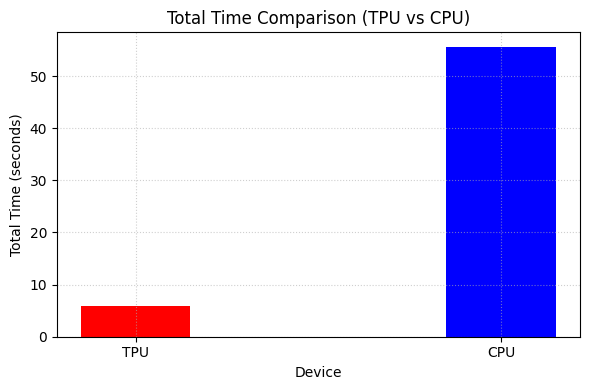

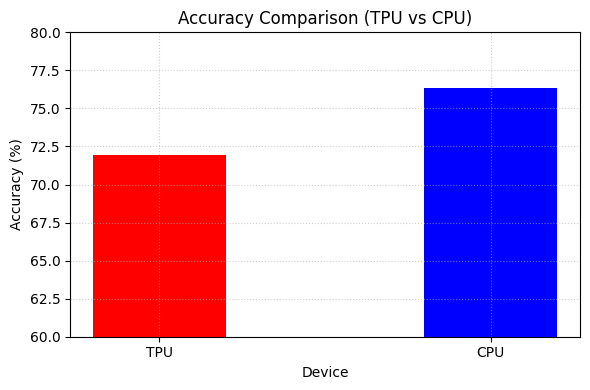

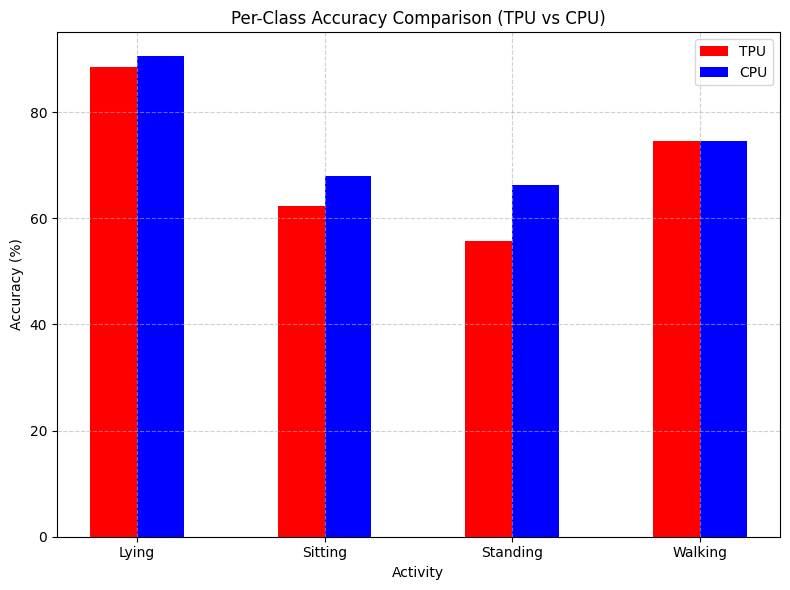

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# === Data ===
devices = ['TPU', 'CPU']
total_time = [5.94, 55.62]  # Total time in seconds
accuracy = [71.92, 76.35]  # Accuracy in percentage

# Per-Class Accuracy Data (TPU and CPU for each activity)
activities = ['Lying', 'Sitting', 'Standing', 'Walking']
tpu_accuracy = [88.42, 62.39, 55.77, 74.48]  # TPU per-class accuracy
cpu_accuracy = [90.52, 67.88, 66.35, 74.48]  # CPU per-class accuracy

# === 1. Total Time Comparison (Bar Plot) ===
plt.figure(figsize=(6, 4))
plt.bar(devices, total_time, color=['red', 'blue'], width=0.3)  # Red for TPU, Blue for CPU
plt.xlabel('Device')
plt.ylabel('Total Time (seconds)')
plt.title('Total Time Comparison (TPU vs CPU)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('../plots/total_time_comparison.png', dpi=300)
plt.show()

# === 2. Accuracy Comparison (Bar Plot) ===
plt.figure(figsize=(6, 4))
plt.bar(devices, accuracy, color=['red', 'blue'], width=0.4)  # Red for TPU, Blue for CPU
plt.xlabel('Device')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Comparison (TPU vs CPU)')
plt.ylim(60, 80)  # Set y-axis limits for better visualization
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('../plots/accuracy_comparison.png', dpi=300)
plt.show()

# === 3. Per-Class Accuracy Comparison (Grouped Bar Plot) ===
x = np.arange(len(activities))  # The label locations
width = 0.25  # Reduced width to 0.25 for narrower bars

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
bars_tpu = ax.bar(x - width/2, tpu_accuracy, width, label='TPU', color='red')  # Red for TPU
bars_cpu = ax.bar(x + width/2, cpu_accuracy, width, label='CPU', color='blue')  # Blue for CPU

# Add some text for labels, title, and custom x-axis tick labels, etc.
ax.set_xlabel('Activity')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy Comparison (TPU vs CPU)')
ax.set_xticks(x)
ax.set_xticklabels(activities)
ax.legend()

# Show grid and layout
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('../plots/per_class_accuracy_comparison.png', dpi=300)
plt.show()
